# 🔬 Chronos-1 vs Chronos-2 Evaluation for RUL Prediction

**Objective**: Compare Chronos foundation models (v1 vs v2) for Remaining Useful Life prediction on C-MAPSS FD001

**Structure**:
- **Part A**: Data Preparation & Feature Selection (Correlation + AFICv)
- **Part B**: Chronos-1 Evaluation (embeddings + regression head)
- **Part C**: Chronos-2 Evaluation (native multivariate)
- **Part D**: Comparison Table

**Key Novelty**: Chronos-2 supports native multivariate forecasting, while Chronos-1 is univariate only.

**Author**: Fatima Khadija Benzine — March 2026

---
## 0. Setup & Installation

In [1]:
# Install dependencies
!pip install -q 'chronos-forecasting>=2.2' xgboost torch

import os
if not os.path.exists('/content/PhD-Project-'):
    !git clone https://github.com/f-khadija-benzine/PhD-Project-.git /content/PhD-Project-

os.chdir('/content/PhD-Project-/src')

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
from datetime import datetime
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import json, time, warnings
warnings.filterwarnings('ignore')

import torch
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

from data_loader import MultiDatasetLoader
from preprocessing import DataNormalizer

TIMESTAMP = datetime.now().strftime('%Y%m%d_%H%M')
SAVE_DIR = f'/content/drive/MyDrive/PhD_results/Chronos_Eval_{TIMESTAMP}'
os.makedirs(SAVE_DIR, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {DEVICE}")
print(f"Save directory: {SAVE_DIR}")
print("Setup complete ✓")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
Save directory: /content/drive/MyDrive/PhD_results/Chronos_Eval_20260307_0415
Setup complete ✓


---
## Part A: Data Preparation & Feature Selection

In [2]:
# === A1: Load C-MAPSS FD001 ===
DATASET = 'FD001'
W = 30
RUL_CAP = 125

loader = MultiDatasetLoader()
ds = loader.load_cmapss_dataset(DATASET)

train_raw = ds['train'].copy()
test_raw = ds['test'].copy()

# Apply RUL cap
train_raw['rul'] = train_raw['rul'].clip(upper=RUL_CAP)
if 'rul' in test_raw.columns:
    test_raw['rul'] = test_raw['rul'].clip(upper=RUL_CAP)

sensor_cols = [c for c in train_raw.columns if c.startswith('sensor_')]
setting_cols = [c for c in train_raw.columns if c.startswith('setting_')]
feature_cols = sensor_cols + setting_cols

print(f"✓ Data loaded")
print(f"  Train: {len(train_raw)} samples, {train_raw['unit'].nunique()} units")
print(f"  Test: {len(test_raw)} samples, {test_raw['unit'].nunique()} units")
print(f"  Features: {len(feature_cols)} ({len(sensor_cols)} sensors + {len(setting_cols)} settings)")

Loading FD001 dataset...
  Files: train=True, test=True, rul=True
  - Training data shape: (20631, 26)
  - Training units: 100
  - Training RUL range: [0, 361]
  - Test data shape: (13096, 26)
  - RUL values shape: (100, 1)
  - Test units found: 100 (units: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]...)
  - RUL values provided: 100
    Unit 1: max_cycle=31, base_RUL=112
    Unit 2: max_cycle=49, base_RUL=98
    Unit 3: max_cycle=126, base_RUL=69
✓ FD001 loaded: 20631 train, 13096 test samples
✓ Data loaded
  Train: 20631 samples, 100 units
  Test: 13096 samples, 100 units
  Features: 24 (21 sensors + 3 settings)


In [3]:
# === A2: Normalization ===
norm = DataNormalizer(method='minmax')
train_norm = norm.fit_transform(train_raw, feature_cols)
test_norm = norm.transform(test_raw)

print(f"✓ Normalization complete (MinMax)")

✓ Normalization complete (MinMax)


In [4]:
# === A3: Feature Selection ===

def variance_filter(df, feature_cols, threshold=0.001):
    """Remove low-variance features"""
    variances = df[feature_cols].var()
    selected = variances[variances > threshold].index.tolist()
    removed = [f for f in feature_cols if f not in selected]
    return selected, removed

def correlation_filter(df, feature_cols, threshold=0.95):
    """Remove highly correlated features"""
    corr_matrix = df[feature_cols].corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    selected = [f for f in feature_cols if f not in to_drop]
    return selected, to_drop

def aficv_selection(df, feature_cols, target_col='rul', threshold=0.90):
    """AFICv: Accumulated Feature Importance with Cross-Validation"""
    X = df[feature_cols].values
    y = df[target_col].values

    model = XGBRegressor(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1)
    model.fit(X, y)

    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]

    cumsum = np.cumsum(importances[indices])
    n_features = np.searchsorted(cumsum, threshold) + 1

    selected_indices = indices[:n_features]
    selected = [feature_cols[i] for i in selected_indices]

    return selected, cumsum[n_features-1]

# Strategy 1: Variance + Correlation filtering
print("=== Strategy 1: Variance + Correlation Filtering ===")
feats_var, removed_var = variance_filter(train_norm, feature_cols, threshold=0.001)
print(f"  Variance filter: {len(feature_cols)} → {len(feats_var)} (removed: {removed_var})")

feats_corr, removed_corr = correlation_filter(train_norm, feats_var, threshold=0.95)
print(f"  Correlation filter: {len(feats_var)} → {len(feats_corr)} (removed: {removed_corr})")

# Strategy 2: AFICv
print("\n=== Strategy 2: AFICv (90% importance coverage) ===")
feats_aficv, coverage = aficv_selection(train_norm, feature_cols, threshold=0.90)
print(f"  Selected: {len(feats_aficv)} features (coverage: {coverage:.1%})")
print(f"  Features: {feats_aficv}")

# Store feature sets
feature_sets = {
    'correlation': feats_corr,
    'aficv': feats_aficv
}

print("\n=== Summary ===")
for name, feats in feature_sets.items():
    print(f"  {name}: {len(feats)} features")

=== Strategy 1: Variance + Correlation Filtering ===
  Variance filter: 24 → 17 (removed: ['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19', 'setting_3'])
  Correlation filter: 17 → 16 (removed: ['sensor_14'])

=== Strategy 2: AFICv (90% importance coverage) ===
  Selected: 8 features (coverage: 90.4%)
  Features: ['sensor_11', 'sensor_9', 'sensor_4', 'sensor_12', 'sensor_20', 'sensor_15', 'sensor_17', 'sensor_14']

=== Summary ===
  correlation: 16 features
  aficv: 8 features


In [5]:
# === A4: Create Sliding Windows ===

def create_sliding_windows(df, feature_cols, window_size=30):
    """Create sliding windows for each unit"""
    X_list, y_list, unit_list = [], [], []

    for unit in sorted(df['unit'].unique()):
        unit_data = df[df['unit'] == unit].sort_values('cycle')
        n_samples = len(unit_data)

        if n_samples < window_size:
            continue

        values = unit_data[feature_cols].values
        ruls = unit_data['rul'].values

        for start in range(n_samples - window_size + 1):
            end = start + window_size
            X_list.append(values[start:end])
            y_list.append(ruls[end - 1])
            unit_list.append(unit)

    return np.array(X_list), np.array(y_list), np.array(unit_list)

# Create windows for each feature set
data_dict = {}

for fs_name, features in feature_sets.items():
    X_train, y_train, units_train = create_sliding_windows(train_norm, features, W)
    X_test, y_test, units_test = create_sliding_windows(test_norm, features, W)

    data_dict[fs_name] = {
        'X_train': X_train, 'y_train': y_train, 'units_train': units_train,
        'X_test': X_test, 'y_test': y_test, 'units_test': units_test,
        'features': features
    }

    print(f"{fs_name}: X_train={X_train.shape}, X_test={X_test.shape}")

print("\n✓ Sliding windows created")

correlation: X_train=(17731, 30, 16), X_test=(10196, 30, 16)
aficv: X_train=(17731, 30, 8), X_test=(10196, 30, 8)

✓ Sliding windows created


In [6]:
# === A5: Evaluation Helpers ===

def nasa_score(y_true, y_pred):
    """NASA asymmetric scoring function (Saxena et al. 2008)"""
    d = y_pred - y_true
    score = np.where(d < 0, np.exp(-d/13) - 1, np.exp(d/10) - 1)
    return np.sum(score)

def evaluate_per_unit(y_true, y_pred, unit_labels):
    """Evaluate using last prediction per unit (standard C-MAPSS protocol)"""
    preds_last, true_last = [], []
    for u in sorted(set(unit_labels)):
        mask = unit_labels == u
        if mask.sum() > 0:
            preds_last.append(y_pred[mask][-1])
            true_last.append(y_true[mask][-1])

    preds_last = np.array(preds_last)
    true_last = np.array(true_last)

    rmse = np.sqrt(mean_squared_error(true_last, preds_last))
    score = nasa_score(true_last, preds_last)
    return rmse, score

ALL_RESULTS = []
print("Evaluation helpers ✓")

Evaluation helpers ✓


---
## Part B: Chronos-1 Evaluation

**Approach**: Extract embeddings using Chronos encoder → Train regression head for RUL prediction

**Note**: Chronos-1 is univariate, so we process each sensor separately and concatenate embeddings.

In [ ]:
# === B1: Load Chronos-1 Pipeline ===
from chronos import ChronosPipeline

CHRONOS1_MODEL = "amazon/chronos-t5-small"

print(f"Loading Chronos-1: {CHRONOS1_MODEL}...")
chronos1_pipeline = ChronosPipeline.from_pretrained(
    CHRONOS1_MODEL,
    device_map=DEVICE,
    torch_dtype=torch.float32
)
print("Chronos-1 loaded ✓")
print(f"  Architecture: T5 encoder-decoder")
print(f"  Capability: Univariate only")

In [ ]:
# === B2: Extract Chronos-1 Embeddings ===

def extract_chronos1_embeddings(pipeline, X, batch_size=32):
    """
    Extract Chronos-1 encoder embeddings.
    X shape: (n_samples, window_size, n_features)
    Since Chronos-1 is univariate, we process each feature and concatenate.
    """
    n_samples, window_size, n_features = X.shape
    all_embeddings = []

    for i in range(0, n_samples, batch_size):
        batch = X[i:i+batch_size]
        batch_embeddings = []

        for feat_idx in range(n_features):
            feat_data = batch[:, :, feat_idx]
            ts_tensor = torch.tensor(feat_data, dtype=torch.float32).to(DEVICE)

            with torch.no_grad():
                emb = pipeline.embed(ts_tensor)
                emb_pooled = emb.mean(dim=1).cpu().numpy()

            batch_embeddings.append(emb_pooled)

        combined = np.concatenate(batch_embeddings, axis=1)
        all_embeddings.append(combined)

        if (i // batch_size) % 10 == 0:
            print(f"    Processed {min(i+batch_size, n_samples)}/{n_samples} samples")

    return np.vstack(all_embeddings)

print("Chronos-1 embedding function defined ✓")

In [ ]:
# === B3: Chronos-1 Evaluation ===

chronos1_results = {}

for fs_name in feature_sets.keys():
    print(f"\n{'='*60}")
    print(f"Chronos-1 + {fs_name.upper()} ({len(feature_sets[fs_name])} features)")
    print('='*60)

    data = data_dict[fs_name]

    print("Extracting train embeddings...")
    start_time = time.time()
    X_train_emb = extract_chronos1_embeddings(chronos1_pipeline, data['X_train'])
    train_time = time.time() - start_time
    print(f"  Shape: {X_train_emb.shape}, Time: {train_time:.1f}s")

    print("Extracting test embeddings...")
    start_time = time.time()
    X_test_emb = extract_chronos1_embeddings(chronos1_pipeline, data['X_test'])
    test_time = time.time() - start_time
    print(f"  Shape: {X_test_emb.shape}, Time: {test_time:.1f}s")

    heads = [
        ('Ridge', Ridge(alpha=1.0)),
        ('MLP', MLPRegressor(hidden_layer_sizes=(256, 128), max_iter=500, random_state=42)),
        ('XGBoost', XGBRegressor(n_estimators=100, max_depth=5, random_state=42))
    ]

    for head_name, head_model in heads:
        print(f"\n  Training {head_name} head...")
        head_model.fit(X_train_emb, data['y_train'])

        y_pred = head_model.predict(X_test_emb)
        rmse, score = evaluate_per_unit(data['y_test'], y_pred, data['units_test'])

        result = {
            'Model': 'Chronos-1',
            'Feature_Set': fs_name,
            'Head': head_name,
            'Test_RMSE': round(rmse, 2),
            'Test_Score': round(score, 1),
            'Time_sec': round(train_time + test_time, 1)
        }
        ALL_RESULTS.append(result)
        chronos1_results[f"{fs_name}_{head_name}"] = result

        print(f"    RMSE: {rmse:.2f}, Score: {score:.1f}")

print("\n✓ Chronos-1 evaluation complete")

---
## Part C: Chronos-2 Evaluation

**Advantage**: Chronos-2 supports native multivariate forecasting via group attention mechanism.

In [7]:
# === C1: Load Chronos-2 Pipeline ===
from chronos import Chronos2Pipeline

CHRONOS2_MODEL = "amazon/chronos-2"

print(f"Loading Chronos-2: {CHRONOS2_MODEL}...")
chronos2_pipeline = Chronos2Pipeline.from_pretrained(
    CHRONOS2_MODEL,
    device_map=DEVICE
)
print("Chronos-2 loaded ✓")
print(f"  Parameters: 120M")
print(f"  Architecture: Encoder-only + Group Attention")
print(f"  Capabilities: Univariate, Multivariate")

Loading Chronos-2: amazon/chronos-2...
Chronos-2 loaded ✓
  Parameters: 120M
  Architecture: Encoder-only + Group Attention
  Capabilities: Univariate, Multivariate


In [8]:
# === C2: Extract Chronos-2 Embeddings (Multivariate) ===

def extract_chronos2_embeddings(pipeline, X, batch_size=32):
    """
    Extract Chronos-2 encoder embeddings.
    Chronos-2 can process multivariate series natively.
    X shape: (n_samples, window_size, n_features)
    """
    n_samples, window_size, n_features = X.shape
    all_embeddings = []

    for i in range(0, n_samples, batch_size):
        batch = X[i:i+batch_size]
        batch_t = np.transpose(batch, (0, 2, 1))

        ts_tensor = torch.tensor(batch_t, dtype=torch.float32)

        with torch.no_grad():
            result = pipeline.embed(ts_tensor)
            # embed() returns (embeddings, loc_scale) tuple
            emb = result[0] if isinstance(result, tuple) else result
            emb_pooled = emb.mean(dim=1).cpu().numpy()

        all_embeddings.append(emb_pooled)

        if (i // batch_size) % 10 == 0:
            print(f"    Processed {min(i+batch_size, n_samples)}/{n_samples} samples")

    return np.vstack(all_embeddings)

print("Chronos-2 embedding function defined ✓")

Chronos-2 embedding function defined ✓


In [9]:
# === C2: Extract Chronos-2 Embeddings (Multivariate) ===

def extract_chronos2_embeddings(pipeline, X, batch_size=32):
    """
    Extract Chronos-2 encoder embeddings.
    X shape: (n_samples, window_size, n_features)
    """
    n_samples, window_size, n_features = X.shape
    all_embeddings = []

    for i in range(0, n_samples, batch_size):
        batch = X[i:i+batch_size]
        batch_t = np.transpose(batch, (0, 2, 1))

        ts_tensor = torch.tensor(batch_t, dtype=torch.float32)

        with torch.no_grad():
            result = pipeline.embed(ts_tensor)

            # embed() returns (list of embeddings, loc_scale)
            emb_list = result[0]
            # Stack list of tensors: (batch, n_features, n_patches, embed_dim)
            emb = torch.stack(emb_list)
            # Mean over features and patches -> (batch, embed_dim)
            emb_pooled = emb.mean(dim=(1, 2)).cpu().numpy()

        all_embeddings.append(emb_pooled)

        if (i // batch_size) % 10 == 0:
            print(f"    Processed {min(i+batch_size, n_samples)}/{n_samples} samples")

    return np.vstack(all_embeddings)

print("Chronos-2 embedding function defined ✓")

Chronos-2 embedding function defined ✓


In [10]:
# === C3: Chronos-2 Evaluation ===

chronos2_results = {}

for fs_name in feature_sets.keys():
    print(f"\n{'='*60}")
    print(f"Chronos-2 + {fs_name.upper()} ({len(feature_sets[fs_name])} features)")
    print('='*60)

    data = data_dict[fs_name]

    print("Extracting train embeddings (multivariate)...")
    start_time = time.time()
    X_train_emb = extract_chronos2_embeddings(chronos2_pipeline, data['X_train'])
    train_time = time.time() - start_time
    print(f"  Shape: {X_train_emb.shape}, Time: {train_time:.1f}s")

    print("Extracting test embeddings...")
    start_time = time.time()
    X_test_emb = extract_chronos2_embeddings(chronos2_pipeline, data['X_test'])
    test_time = time.time() - start_time
    print(f"  Shape: {X_test_emb.shape}, Time: {test_time:.1f}s")
    #for seed in [42, 123, 456, 789, 2024]:
    heads = [
        ('Ridge', Ridge(alpha=1.0)),
        ('MLP', MLPRegressor(hidden_layer_sizes=(256, 128), max_iter=500, random_state=123)),
        ('XGBoost', XGBRegressor(n_estimators=100, max_depth=5, random_state=123))
    ]

    for head_name, head_model in heads:
        print(f"\n  Training {head_name} head...")
        head_model.fit(X_train_emb, data['y_train'])

        y_pred = head_model.predict(X_test_emb)
        rmse, score = evaluate_per_unit(data['y_test'], y_pred, data['units_test'])

        result = {
            'Model': 'Chronos-2',
            'Feature_Set': fs_name,
            'Head': head_name,
            'Test_RMSE': round(rmse, 2),
            'Test_Score': round(score, 1),
            'Time_sec': round(train_time + test_time, 1)
        }
        ALL_RESULTS.append(result)
        chronos2_results[f"{fs_name}_{head_name}"] = result

        print(f"    RMSE: {rmse:.2f}, Score: {score:.1f}")

print("\n✓ Chronos-2 evaluation complete")


Chronos-2 + CORRELATION (16 features)
Extracting train embeddings (multivariate)...
    Processed 32/17731 samples
    Processed 352/17731 samples
    Processed 672/17731 samples
    Processed 992/17731 samples
    Processed 1312/17731 samples
    Processed 1632/17731 samples
    Processed 1952/17731 samples
    Processed 2272/17731 samples
    Processed 2592/17731 samples
    Processed 2912/17731 samples
    Processed 3232/17731 samples
    Processed 3552/17731 samples
    Processed 3872/17731 samples
    Processed 4192/17731 samples
    Processed 4512/17731 samples
    Processed 4832/17731 samples
    Processed 5152/17731 samples
    Processed 5472/17731 samples
    Processed 5792/17731 samples
    Processed 6112/17731 samples
    Processed 6432/17731 samples
    Processed 6752/17731 samples
    Processed 7072/17731 samples
    Processed 7392/17731 samples
    Processed 7712/17731 samples
    Processed 8032/17731 samples
    Processed 8352/17731 samples
    Processed 8672/17731 samp

In [ ]:
# === C4: LSTM and BiLSTM Heads ===
import torch.nn as nn
# Set seed for reproducibility
SEED = 123
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)

class LSTMHead(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers,
                            batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x: (batch, features) -> (batch, 1, features)
        x = x.unsqueeze(1)
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out.squeeze()

class BiLSTMHead(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.bilstm = nn.LSTM(input_dim, hidden_dim, num_layers,
                              batch_first=True, dropout=dropout, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 1)  # *2 for bidirectional

    def forward(self, x):
        x = x.unsqueeze(1)
        out, _ = self.bilstm(x)
        out = self.fc(out[:, -1, :])
        return out.squeeze()

def train_torch_head(model, X_train, y_train, X_test, epochs=100, lr=0.001):
    """Train PyTorch model and return predictions"""
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    X_train_t = torch.tensor(X_train, dtype=torch.float32).to(DEVICE)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).to(DEVICE)
    X_test_t = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)

    # Training
    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        pred = model(X_train_t)
        loss = criterion(pred, y_train_t)
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 20 == 0:
            print(f"      Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

    # Prediction
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test_t).cpu().numpy()

    return y_pred

print("LSTM and BiLSTM heads defined ✓")

In [ ]:
# === C5: Evaluate LSTM/BiLSTM Heads on Chronos-2 Embeddings ===

# Use the correlation feature set (best performing)
fs_name = 'correlation'
data = data_dict[fs_name]

# Flatten embeddings if needed (should already be 2D from previous fix)
X_train_emb_flat = X_train_emb.reshape(X_train_emb.shape[0], -1)
X_test_emb_flat = X_test_emb.reshape(X_test_emb.shape[0], -1)

input_dim = X_train_emb_flat.shape[1]
print(f"Embedding dimension: {input_dim}")

# Test LSTM Head
print("\n  Training LSTM head...")
lstm_head = LSTMHead(input_dim, hidden_dim=128, num_layers=2)
y_pred_lstm = train_torch_head(lstm_head, X_train_emb_flat, data['y_train'], X_test_emb_flat, epochs=100)
rmse_lstm, score_lstm = evaluate_per_unit(data['y_test'], y_pred_lstm, data['units_test'])
print(f"    LSTM: RMSE={rmse_lstm:.2f}, Score={score_lstm:.1f}")

# Test BiLSTM Head
print("\n  Training BiLSTM head...")
bilstm_head = BiLSTMHead(input_dim, hidden_dim=128, num_layers=2)
y_pred_bilstm = train_torch_head(bilstm_head, X_train_emb_flat, data['y_train'], X_test_emb_flat, epochs=100)
rmse_bilstm, score_bilstm = evaluate_per_unit(data['y_test'], y_pred_bilstm, data['units_test'])
print(f"    BiLSTM: RMSE={rmse_bilstm:.2f}, Score={score_bilstm:.1f}")

# Add to results
ALL_RESULTS.append({'Model': 'Chronos-2', 'Feature_Set': fs_name, 'Head': 'LSTM',
                    'Test_RMSE': round(rmse_lstm, 2), 'Test_Score': round(score_lstm, 1), 'Time_sec': 0})
ALL_RESULTS.append({'Model': 'Chronos-2', 'Feature_Set': fs_name, 'Head': 'BiLSTM',
                    'Test_RMSE': round(rmse_bilstm, 2), 'Test_Score': round(score_bilstm, 1), 'Time_sec': 0})

print("\n✓ LSTM/BiLSTM evaluation complete")

---
## Part D: Comparison

In [11]:
# === D1: Results Table ===
results_df = pd.DataFrame(ALL_RESULTS)
results_df = results_df.sort_values('Test_RMSE')

print("\n" + "="*80)
print("RESULTS: Chronos-2 on C-MAPSS FD001")
print("="*80)
print(results_df.to_string(index=False))

print("\n" + "="*80)
print("BASELINES (from IMSA2025 paper)")
print("="*80)
baselines = [
    {'Model': 'XGBoost (direct)', 'RMSE': 14.64, 'Score': 307.13},
    {'Model': 'Classical LSTM', 'RMSE': 16.14, 'Score': 397.75},
    {'Model': 'Proposed LSTM (IMSA2025)', 'RMSE': 14.32, 'Score': 325.05},
    {'Model': 'Chronos-1 + XGBoost', 'RMSE': 15.93, 'Score': 379.02},
    {'Model': 'Chronos-1 + ANN', 'RMSE': 14.92, 'Score': 641.58},
]
baselines_df = pd.DataFrame(baselines)
print(baselines_df.to_string(index=False))

# Combined comparison
print("\n" + "="*80)
print("FULL COMPARISON (sorted by RMSE)")
print("="*80)

# Best Chronos-2 results per head
best_c2 = results_df[results_df['Feature_Set'] == 'correlation'][['Model', 'Head', 'Test_RMSE', 'Test_Score']]
best_c2 = best_c2.rename(columns={'Test_RMSE': 'RMSE', 'Test_Score': 'Score'})
best_c2['Model'] = 'Chronos-2 + ' + best_c2['Head']
best_c2 = best_c2[['Model', 'RMSE', 'Score']]

# Combine with baselines
full_comparison = pd.concat([best_c2, baselines_df], ignore_index=True)
full_comparison = full_comparison.sort_values('RMSE')
print(full_comparison.to_string(index=False))

# Highlight best
best = full_comparison.iloc[0]
print(f"\n🏆 Best overall: {best['Model']} (RMSE={best['RMSE']}, Score={best['Score']})")


RESULTS: Chronos-1 vs Chronos-2 on C-MAPSS FD001
    Model Feature_Set    Head  Test_RMSE  Test_Score  Time_sec
Chronos-2 correlation XGBoost      14.85       382.1     189.1
Chronos-2 correlation     MLP      15.27       454.5     189.1
Chronos-2 correlation   Ridge      15.68       387.9     189.1
Chronos-2       aficv   Ridge      19.17       936.3      89.1
Chronos-2       aficv XGBoost      21.22      1879.8      89.1
Chronos-2       aficv     MLP      22.24      2964.5      89.1

BASELINES (from IMSA2025 paper)
            Model  RMSE  Score
          XGBoost 14.64 307.13
   Classical LSTM 16.14 397.75
    Proposed LSTM 14.32 325.05
Chronos + XGBoost 15.93 379.02
    Chronos + ANN 14.92 641.58


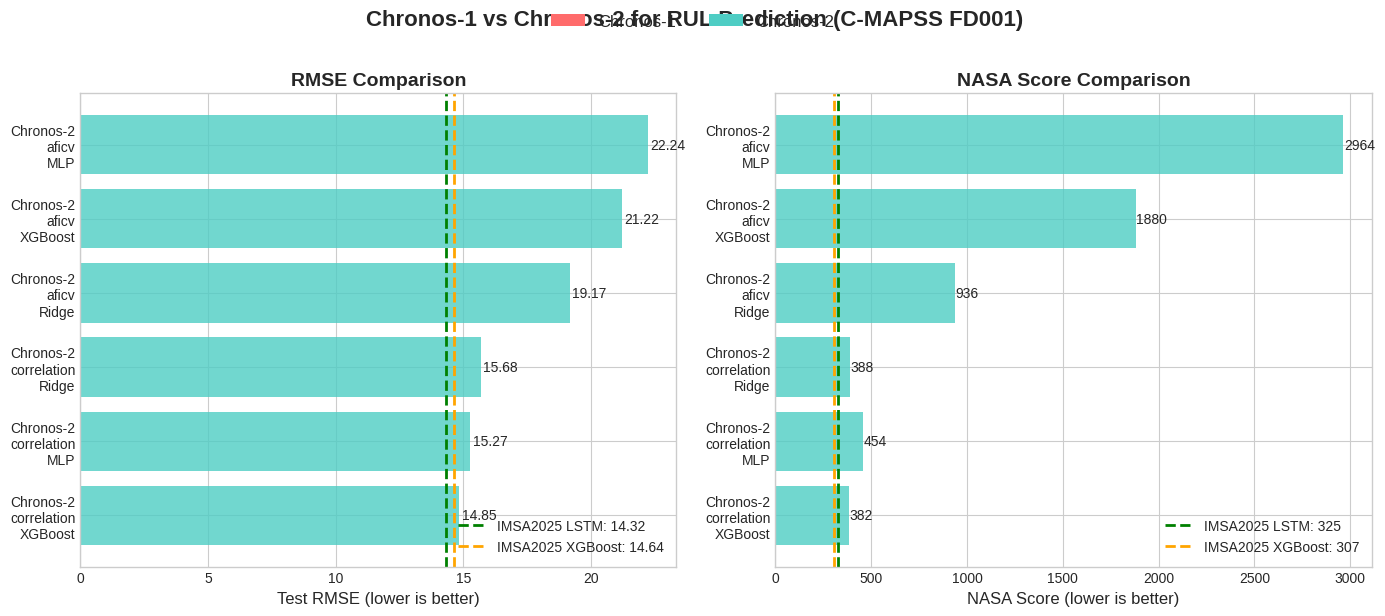

In [12]:
# === D2: Visualization ===
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Filter only correlation features (best performing)
chronos_df = results_df[results_df['Feature_Set'] == 'correlation'].copy()
chronos_df['Label'] = chronos_df['Head']
chronos_df = chronos_df.sort_values('Test_RMSE')

# Color by head type
head_colors = {
    'Ridge': '#3498db',
    'MLP': '#9b59b6',
    'XGBoost': '#e74c3c',
    'LSTM': '#2ecc71',
    'BiLSTM': '#1abc9c'
}
colors = [head_colors.get(h, '#95a5a6') for h in chronos_df['Head']]

# RMSE
ax1 = axes[0]
bars1 = ax1.barh(chronos_df['Label'], chronos_df['Test_RMSE'], color=colors, alpha=0.8)
ax1.axvline(x=14.32, color='green', linestyle='--', linewidth=2, label='Proposed LSTM (IMSA2025): 14.32')
ax1.axvline(x=14.64, color='orange', linestyle='--', linewidth=2, label='XGBoost direct: 14.64')
ax1.axvline(x=15.93, color='red', linestyle=':', linewidth=2, label='Chronos-1 + XGBoost: 15.93')
ax1.set_xlabel('Test RMSE (lower is better)', fontsize=12)
ax1.set_title('RMSE Comparison', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right', fontsize=9)

for bar, val in zip(bars1, chronos_df['Test_RMSE']):
    ax1.text(val + 0.1, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center')

# NASA Score
ax2 = axes[1]
bars2 = ax2.barh(chronos_df['Label'], chronos_df['Test_Score'], color=colors, alpha=0.8)
ax2.axvline(x=325.05, color='green', linestyle='--', linewidth=2, label='Proposed LSTM (IMSA2025): 325')
ax2.axvline(x=307.13, color='orange', linestyle='--', linewidth=2, label='XGBoost direct: 307')
ax2.axvline(x=379.02, color='red', linestyle=':', linewidth=2, label='Chronos-1 + XGBoost: 379')
ax2.set_xlabel('NASA Score (lower is better)', fontsize=12)
ax2.set_title('NASA Score Comparison', fontsize=14, fontweight='bold')
ax2.legend(loc='lower right', fontsize=9)

for bar, val in zip(bars2, chronos_df['Test_Score']):
    ax2.text(val + 5, bar.get_y() + bar.get_height()/2, f'{val:.0f}', va='center')

plt.suptitle('Chronos-2 + Different Heads for RUL Prediction (C-MAPSS FD001)\nFeature Set: Correlation',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/chronos2_heads_comparison_{TIMESTAMP}.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# === D3: Save Results ===
results_df.to_csv(f'{SAVE_DIR}/chronos2_results_{TIMESTAMP}.csv', index=False)

best = results_df.iloc[0].to_dict()
with open(f'{SAVE_DIR}/best_result_{TIMESTAMP}.json', 'w') as f:
    json.dump(best, f, indent=2, default=str)

# Save full comparison with baselines
full_comparison.to_csv(f'{SAVE_DIR}/full_comparison_{TIMESTAMP}.csv', index=False)

summary = {
    'dataset': 'C-MAPSS FD001',
    'window_size': W,
    'rul_cap': RUL_CAP,
    'chronos2_model': CHRONOS2_MODEL,
    'best_model': best['Model'],
    'best_features': best['Feature_Set'],
    'best_head': best['Head'],
    'best_rmse': best['Test_RMSE'],
    'best_score': best['Test_Score'],
    'heads_tested': ['Ridge', 'MLP', 'XGBoost', 'LSTM', 'BiLSTM'],
    'feature_sets_tested': ['correlation', 'aficv'],
    'baselines': {
        'proposed_lstm_imsa2025': {'rmse': 14.32, 'score': 325.05},
        'xgboost_direct': {'rmse': 14.64, 'score': 307.13},
        'chronos1_xgboost': {'rmse': 15.93, 'score': 379.02}
    }
}
with open(f'{SAVE_DIR}/summary_{TIMESTAMP}.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(f"\n✓ Results saved to {SAVE_DIR}")
print(f"\n{'='*60}")
print("BEST CHRONOS-2 RESULT:")
print(f"  Features: {best['Feature_Set']}")
print(f"  Head: {best['Head']}")
print(f"  RMSE: {best['Test_RMSE']}")
print(f"  Score: {best['Test_Score']}")
print('='*60)

print(f"\n{'='*60}")
print("COMPARISON WITH BASELINES:")
print(f"  vs Proposed LSTM (14.32):    {'+' if best['Test_RMSE'] > 14.32 else '-'}{abs(best['Test_RMSE'] - 14.32):.2f} RMSE")
print(f"  vs XGBoost direct (14.64):   {'+' if best['Test_RMSE'] > 14.64 else '-'}{abs(best['Test_RMSE'] - 14.64):.2f} RMSE")
print(f"  vs Chronos-1 + XGB (15.93):  {'+' if best['Test_RMSE'] > 15.93 else '-'}{abs(best['Test_RMSE'] - 15.93):.2f} RMSE")
print('='*60)

NameError: name 'CHRONOS1_MODEL' is not defined

---
## Summary

### Experimental Setup
- **Dataset**: C-MAPSS FD001 (100 train units, 100 test units)
- **Window size**: 30 cycles
- **Feature selection**: Variance+Correlation, AFICv (90% importance)
- **Metrics**: RMSE and NASA Score (per-unit last prediction)

### Model Comparison

| Aspect | Chronos-1 | Chronos-2 |
|--------|-----------|----------|
| Architecture | T5 Encoder-Decoder | Encoder + Group Attention |
| Multivariate | ❌ (process separately) | ✅ Native |
| Parameters | 8M-710M (configurable) | 120M |
| Context Length | 512 | 8192 |

### Files Saved
```
PhD_results/Chronos_Eval_YYYYMMDD_HHMM/
    chronos_results_*.csv
    chronos_comparison_*.png
    best_result_*.json
    summary_*.json
```